# Lib1 All-Region Phase 1 Performance Summary (June 10, 2026)

This notebook collects the current validation-selected Phase 1 model performance across CRE regions.

Sources:
- Promoter, intron, and 3UTR scratch HPO registry used by `pretrain_CRE_inhouse_data/lib1_inhouse_scratch_hpo_best_models_june2026.ipynb`.
- 5UTR fine-tuning HPO outputs used by `fine_tuning/fivePrime_finetune_w_lib1_hani_pretrain/inhouse_utr5_parade_resnet_small_hpo_analysis_jun2026.ipynb`.
- Enhancer multi-seed fine-tuning HPO outputs used by `fine_tuning/enhancer_finetune_w_boda_pretrain/may15_2026_hq8_multiseed_hpo_analysis.ipynb`.

Selection rule: choose the run/configuration with the best validation Pearson within each region-specific source, then report the matched heldout test Pearson. The max-test rows are shown separately as diagnostics, not as the primary selection rule.

In [1]:
from pathlib import Path
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)


def find_boda_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    candidates = [start, start / "boda2_EU", Path("/home/minhang/synBio_AL/boda2_EU")]
    candidates.extend(start.parents)
    for candidate in candidates:
        if (candidate / "src/learn/run_registry/runs.csv").exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not find boda2_EU repo root from the current working directory.")


REPO_ROOT = find_boda_repo_root()
RUN_REGISTRY = REPO_ROOT / "src/learn/run_registry"
LC_ROOT = REPO_ROOT / "src/finetune/learning_curve"

SCRATCH_NOTEBOOK = REPO_ROOT / "tutorials/lib1_tasks/pretrain_CRE_inhouse_data/lib1_inhouse_scratch_hpo_best_models_june2026.ipynb"
UTR5_NOTEBOOK = REPO_ROOT / "tutorials/lib1_tasks/fine_tuning/fivePrime_finetune_w_lib1_hani_pretrain/inhouse_utr5_parade_resnet_small_hpo_analysis_jun2026.ipynb"
ENHANCER_NOTEBOOK = REPO_ROOT / "tutorials/lib1_tasks/fine_tuning/enhancer_finetune_w_boda_pretrain/may15_2026_hq8_multiseed_hpo_analysis.ipynb"

source_paths = pd.DataFrame([
    {"source": "scratch HPO notebook", "path": SCRATCH_NOTEBOOK, "exists": SCRATCH_NOTEBOOK.exists()},
    {"source": "5UTR fine-tune notebook", "path": UTR5_NOTEBOOK, "exists": UTR5_NOTEBOOK.exists()},
    {"source": "enhancer fine-tune notebook", "path": ENHANCER_NOTEBOOK, "exists": ENHANCER_NOTEBOOK.exists()},
    {"source": "scratch run registry", "path": RUN_REGISTRY / "runs.csv", "exists": (RUN_REGISTRY / "runs.csv").exists()},
])
display(source_paths)
print("REPO_ROOT:", REPO_ROOT)

,source,path,exists
0,scratch HPO notebook,/home/minhang/synBio_AL/boda2_EU/tutorials/lib...,True
1,5UTR fine-tune notebook,/home/minhang/synBio_AL/boda2_EU/tutorials/lib...,True
2,enhancer fine-tune notebook,/home/minhang/synBio_AL/boda2_EU/tutorials/lib...,True
3,scratch run registry,/home/minhang/synBio_AL/boda2_EU/src/learn/run...,True


REPO_ROOT: /home/minhang/synBio_AL/boda2_EU


## Scratch HPO: promoter, intron, and 3UTR

For scratch HPO, we use the same project mapping as the June 2026 best-model notebook and select within each CRE region using validation Pearson. The 3UTR row is intentionally strict: the current best validation run has a substantially lower matched test score than the best-test diagnostic run.

In [2]:
SCRATCH_PROJECT_ROWS = [
    {
        "logger_project": "promoter__bashor_in_house__lib1_allvalid__scratch__resnet1d",
        "cre_region": "Promoter",
        "architecture": "ResNet1D",
        "run_family": "June standard",
        "selection_scope": "main",
    },
    {
        "logger_project": "promoter__bashor_in_house__lib1_allvalid__scratch__promoter_bassetvl",
        "cre_region": "Promoter",
        "architecture": "BassetVL",
        "run_family": "June standard",
        "selection_scope": "main",
    },
    {
        "logger_project": "introns__bashor_in_house__lib1_intron_modal80__scratch__resnet1d",
        "cre_region": "Intron",
        "architecture": "ResNet1D",
        "run_family": "June standard",
        "selection_scope": "main",
    },
    {
        "logger_project": "utr3__bashor_in_house__threeprime_modal100__scratch__resnet1d_fp32",
        "cre_region": "3UTR",
        "architecture": "ResNet1D",
        "run_family": "June standard",
        "selection_scope": "main",
    },
    {
        "logger_project": "utr3__bashor_in_house__threeprime_modal100__scratch__utr_bassetvl_fp32",
        "cre_region": "3UTR",
        "architecture": "BassetVL",
        "run_family": "June standard",
        "selection_scope": "main",
    },
    {
        "logger_project": "utr3__bashor_in_house__threeprime_modal100__scratch__utr_bassetvl_focused_rc_factorial_fp32",
        "cre_region": "3UTR",
        "architecture": "BassetVL",
        "run_family": "focused RC grid",
        "selection_scope": "main",
    },
]

REGION_ORDER = ["Promoter", "Intron", "3UTR", "5UTR", "Enhancer"]
REGION_ORDER_MAP = {region: idx for idx, region in enumerate(REGION_ORDER)}


def coerce_metric_columns(frame, cols):
    frame = frame.copy()
    for col in cols:
        if col in frame.columns:
            frame[col] = pd.to_numeric(frame[col], errors="coerce")
    return frame


def load_scratch_hpo_runs():
    project_table = pd.DataFrame(SCRATCH_PROJECT_ROWS)
    runs = pd.read_csv(RUN_REGISTRY / "runs.csv", low_memory=False)
    subset = runs.merge(project_table, on="logger_project", how="inner")
    metric_cols = [
        "best_epoch", "best_metric_value", "val_loss", "val_r2", "val_pearson", "val_spearman",
        "test_loss", "test_r2", "test_pearson", "test_spearman", "train_loss", "train_r2",
        "train_pearson", "train_spearman", "val_cod_r2", "test_cod_r2", "train_cod_r2",
    ]
    subset = coerce_metric_columns(subset, metric_cols)
    subset["invalid_pearson"] = subset[["val_pearson", "test_pearson", "train_pearson"]].abs().gt(1).any(axis=1)
    subset["selection_ready"] = (
        subset["status"].eq("completed")
        & subset["selection_scope"].eq("main")
        & ~subset["invalid_pearson"]
        & subset["val_pearson"].notna()
        & subset["test_pearson"].notna()
    )
    return subset


scratch_runs = load_scratch_hpo_runs()
scratch_ok = scratch_runs[scratch_runs["selection_ready"]].copy()

scratch_project_summary = (
    scratch_ok.groupby(["cre_region", "architecture", "run_family", "logger_project"], observed=True)
    .agg(
        n_completed_ok=("run_id", "nunique"),
        val_pearson_max=("val_pearson", "max"),
        test_pearson_max=("test_pearson", "max"),
        latest_registry_timestamp=("timestamp", "max"),
    )
    .reset_index()
    .sort_values(["cre_region", "architecture", "run_family"])
)

display(scratch_project_summary)

,cre_region,architecture,run_family,logger_project,n_completed_ok,val_pearson_max,test_pearson_max,latest_registry_timestamp
0,3UTR,BassetVL,June standard,utr3__bashor_in_house__threeprime_modal100__sc...,160,0.378506,0.586879,2026-06-10T09:37:50
1,3UTR,BassetVL,focused RC grid,utr3__bashor_in_house__threeprime_modal100__sc...,128,0.436791,0.447668,2026-06-09T05:10:40
2,3UTR,ResNet1D,June standard,utr3__bashor_in_house__threeprime_modal100__sc...,159,0.455851,0.477185,2026-06-10T09:51:46
3,Intron,ResNet1D,June standard,introns__bashor_in_house__lib1_intron_modal80_...,158,0.613275,0.718299,2026-06-10T06:06:09
4,Promoter,BassetVL,June standard,promoter__bashor_in_house__lib1_allvalid__scra...,176,0.425197,0.391424,2026-06-10T04:19:30
5,Promoter,ResNet1D,June standard,promoter__bashor_in_house__lib1_allvalid__scra...,160,0.387018,0.393222,2026-06-10T03:56:35


In [3]:
def wandb_config_path_for_run(run_id):
    matches = sorted((REPO_ROOT / "src/learn/wandb").glob(f"run-*{run_id}/files/config.yaml"))
    return matches[0] if matches else None


def _config_block(text, key):
    match = re.search(rf"^{re.escape(key)}:\n(?P<body>.*?)(?=^[A-Za-z0-9_. -]+:\n|\Z)", text, flags=re.M | re.S)
    return match.group("body") if match else ""


def _raw_config_value(block):
    lines = block.splitlines()
    for idx, line in enumerate(lines):
        if re.match(r"\s*value:\s*", line):
            value = line.split("value:", 1)[1].strip()
            if value:
                return value.strip('"').strip("'")
            items = []
            for nxt in lines[idx + 1:]:
                if re.match(r"\s*-\s+", nxt):
                    items.append(re.sub(r"^\s*-\s*", "", nxt).strip().strip('"').strip("'"))
                elif nxt.strip() and not nxt.startswith(" "):
                    break
            return items
    return None


def _coerce_config_value(value):
    if value is None:
        return np.nan
    if isinstance(value, list):
        return value
    text = str(value).strip()
    if text.lower() in {"none", "null", "nan"}:
        return np.nan
    if text.lower() == "true":
        return True
    if text.lower() == "false":
        return False
    try:
        if any(ch in text.lower() for ch in [".", "e"]):
            return float(text)
        return int(text)
    except ValueError:
        return text


def parse_wandb_config(run_id, keys):
    path = wandb_config_path_for_run(run_id)
    out = {"wandb_config_path": str(path) if path else None}
    if path is None:
        for key in keys:
            out[key] = np.nan
        return out
    text = path.read_text()
    for key in keys:
        out[key] = _coerce_config_value(_raw_config_value(_config_block(text, key)))
    return out


def count_hq_rows(datafile_path, min_barcodes=8):
    if pd.isna(datafile_path):
        return np.nan
    path = Path(str(datafile_path))
    if not path.exists():
        return np.nan
    try:
        barcodes = pd.read_csv(path, sep="\t", usecols=["n_barcodes"])["n_barcodes"]
    except Exception:
        return np.nan
    return int((pd.to_numeric(barcodes, errors="coerce") >= float(min_barcodes)).sum())


def heldout_sizes_from_run_config(run_id):
    keys = [
        "datafile_path", "split_seed", "test_min_barcodes", "train_min_barcodes",
        "val_frac_within_hq", "test_frac_within_hq", "val_size_within_hq", "test_size_within_hq",
        "use_reverse_complements", "model_seed", "lr", "weight_decay",
    ]
    cfg = parse_wandb_config(run_id, keys)
    hq_n = count_hq_rows(cfg.get("datafile_path"), cfg.get("test_min_barcodes", 8))
    cfg["n_high_quality_rows"] = hq_n
    for split in ["val", "test"]:
        size_key = f"{split}_size_within_hq"
        frac_key = f"{split}_frac_within_hq"
        value = cfg.get(size_key)
        if pd.isna(value) and not pd.isna(hq_n) and not pd.isna(cfg.get(frac_key)):
            value = int(round(hq_n * float(cfg[frac_key])))
            cfg[f"{split}_size_source"] = "inferred from rounded HQ fraction"
        else:
            cfg[f"{split}_size_source"] = "configured explicit size" if not pd.isna(value) else "not available"
        cfg[size_key] = value
    return cfg


def bool_label(value):
    if pd.isna(value):
        return "unknown"
    return "RC on" if bool(value) else "RC off"


def scratch_validation_selected_by_region():
    selected = (
        scratch_ok.sort_values(["cre_region", "val_pearson", "test_pearson"], ascending=[True, False, False])
        .drop_duplicates("cre_region")
        .copy()
    )
    rows = []
    for _, row in selected.iterrows():
        cfg = heldout_sizes_from_run_config(row["run_id"])
        rows.append({
            "region": row["cre_region"],
            "source": "scratch HPO registry",
            "selection_rule": "max validation Pearson within region",
            "model_label": f"{row['architecture']} ({row['run_family']})",
            "run_id": row["run_id"],
            "run_name": row["run_name"],
            "val_pearson": row["val_pearson"],
            "test_pearson": row["test_pearson"],
            "test_pearson_se": np.nan,
            "best_epoch": row["best_epoch"],
            "n_val": cfg.get("val_size_within_hq"),
            "n_test": cfg.get("test_size_within_hq"),
            "n_high_quality_rows": cfg.get("n_high_quality_rows"),
            "heldout_note": f"HQ min barcode {cfg.get('test_min_barcodes')}; {cfg.get('val_size_source')} / {cfg.get('test_size_source')}",
            "split_seed": cfg.get("split_seed"),
            "n_runs_or_seeds": int(scratch_ok[scratch_ok["cre_region"].eq(row["cre_region"])] ["run_id"].nunique()),
            "rc_state": bool_label(cfg.get("use_reverse_complements")),
            "extra": f"architecture={row['architecture']}; family={row['run_family']}",
        })
    return pd.DataFrame(rows)


scratch_selected = scratch_validation_selected_by_region()

display(scratch_selected[[
    "region", "model_label", "run_id", "run_name", "val_pearson", "test_pearson", "best_epoch",
    "n_val", "n_test", "n_high_quality_rows", "split_seed", "rc_state", "n_runs_or_seeds", "heldout_note",
]])

scratch_max_test = (
    scratch_ok.sort_values(["cre_region", "test_pearson", "val_pearson"], ascending=[True, False, False])
    .drop_duplicates("cre_region")
    .copy()
)
display(scratch_max_test[[
    "cre_region", "architecture", "run_family", "run_id", "run_name", "best_epoch", "val_pearson", "test_pearson",
]].sort_values("cre_region"))

,region,model_label,run_id,run_name,val_pearson,test_pearson,best_epoch,n_val,n_test,n_high_quality_rows,split_seed,rc_state,n_runs_or_seeds,heldout_note
0,3UTR,ResNet1D (June standard),8xcp9her,threeprime_modal100_resnet1d_fp32_7g4izye6,0.455851,0.085764,80,194,194,775,101,RC off,447,HQ min barcode 8; inferred from rounded HQ fra...
1,Intron,ResNet1D (June standard),glgcweci,lib1_intron_modal80_resnet1d_scratch_b2sb3jdj,0.613275,0.654137,78,250,250,1326,101,RC on,158,HQ min barcode 8; configured explicit size / c...
2,Promoter,BassetVL (June standard),cqg85h6j,lib1_promoter_promoter_bassetvl_scratch_xprp6ayp,0.425197,0.350152,73,250,250,1931,101,RC off,336,HQ min barcode 8; configured explicit size / c...


,cre_region,architecture,run_family,run_id,run_name,best_epoch,val_pearson,test_pearson
315,3UTR,BassetVL,June standard,pn50zxhm,threeprime_modal100_utr_bassetvl_fp32_d1xfzh7y,24,0.282984,0.586879
462,Intron,ResNet1D,June standard,pkc2c2aa,lib1_intron_modal80_resnet1d_scratch_6f4gf0ab,21,0.483080,0.718299
615,Promoter,ResNet1D,June standard,8xqjbyeg,lib1_promoter_resnet1d_scratch_l38rv22u,20,0.272756,0.393222


## 5UTR fine-tuning HPO

The 5UTR source table stores both pretrained baselines and fine-tuned models. Here, `is_finetuned` is derived from the model label and selection is by validation Pearson among fine-tuned configurations.

In [4]:
UTR5_COMBINED = LC_ROOT / "inhouse_utr5_parade_resnet_small_hpo_jun2026/combined"


def prefer_top_level_sources(frame):
    if "source_job_dir" not in frame.columns:
        return frame.drop_duplicates().reset_index(drop=True)
    dedupe_cols = [col for col in frame.columns if col != "source_job_dir"]
    tmp = frame.copy()
    tmp["_source_depth"] = tmp["source_job_dir"].fillna("").astype(str).str.count("/")
    return (
        tmp.sort_values("_source_depth")
        .drop_duplicates(dedupe_cols)
        .drop(columns="_source_depth")
        .reset_index(drop=True)
    )


def matching_test_row(val_row, test_frame, key_cols):
    mask = pd.Series(True, index=test_frame.index)
    for col in key_cols:
        left = val_row[col]
        right = test_frame[col]
        if pd.isna(left):
            mask &= right.isna()
        else:
            mask &= right.astype(str).eq(str(left))
    matched = test_frame[mask].copy()
    if matched.empty:
        raise ValueError(f"No matched test row for {val_row.get('model_label')}")
    return matched.iloc[0]


def load_utr5_summary():
    summary = pd.read_csv(UTR5_COMBINED / "model_comparison_summary.csv")
    summary = prefer_top_level_sources(summary)
    summary["is_finetuned"] = summary["model_label"].astype(str).str.startswith("finetuned__")
    summary = coerce_metric_columns(summary, ["pearson", "spearman", "cod_r2", "best_epoch", "n", "actual_train_size"])
    val = summary[summary["is_finetuned"] & summary["split"].eq("val")].copy()
    test = summary[summary["is_finetuned"] & summary["split"].eq("test")].copy()
    key_cols = [
        "model_label", "model_family", "cell_head", "train_threshold", "train_size", "run_seed",
        "unfreeze_scope", "head_lr", "backbone_lr", "freeze_backbone_epochs", "weight_decay",
        "target", "target_scaler_source",
    ]
    val_best = val.sort_values(["pearson", "spearman"], ascending=False).iloc[0]
    test_match = matching_test_row(val_best, test, key_cols)
    split_summary = prefer_top_level_sources(pd.read_csv(UTR5_COMBINED / "split_membership_summary.csv"))
    split_sizes = split_summary[split_summary["split"].isin(["val", "test"])] .set_index("split")
    val_n = int(split_sizes.loc["val", "n"]) if "val" in split_sizes.index else int(val_best["n"])
    test_n = int(split_sizes.loc["test", "n"]) if "test" in split_sizes.index else int(test_match["n"])
    train_pool_rows = split_summary[split_summary["split"].eq("train_pool")]
    if not train_pool_rows.empty and "n_high_quality_rows" in train_pool_rows.columns:
        hq_rows = int(train_pool_rows["n_high_quality_rows"].max())
    elif "n_high_quality_rows" in split_summary.columns:
        hq_rows = int(split_summary["n_high_quality_rows"].max())
    else:
        hq_rows = np.nan
    row = {
        "region": "5UTR",
        "source": "5UTR fine-tune HPO summary",
        "selection_rule": "max validation Pearson among fine-tuned configs",
        "model_label": f"{val_best['model_family']} {val_best['cell_head']} threshold {int(val_best['train_threshold'])} {val_best['unfreeze_scope']}",
        "run_id": val_best["model_label"],
        "run_name": val_best["model_label"],
        "val_pearson": float(val_best["pearson"]),
        "test_pearson": float(test_match["pearson"]),
        "test_pearson_se": np.nan,
        "best_epoch": float(val_best["best_epoch"]),
        "n_val": val_n,
        "n_test": test_n,
        "n_high_quality_rows": hq_rows,
        "heldout_note": "HQ min barcode 8; val/test rows from split summary",
        "split_seed": val_best.get("run_seed"),
        "n_runs_or_seeds": int(val.drop_duplicates(key_cols).shape[0]),
        "rc_state": "not varied here",
        "extra": f"actual_train_size={int(val_best['actual_train_size'])}; monitor={val_best.get('best_monitor_metric')}",
    }
    return row, summary, split_summary


utr5_row, utr5_summary, utr5_split_summary = load_utr5_summary()
display(pd.DataFrame([utr5_row]))
display(utr5_split_summary.sort_values(["split", "train_threshold"], na_position="first"))

,region,source,selection_rule,model_label,run_id,run_name,val_pearson,test_pearson,test_pearson_se,best_epoch,n_val,n_test,n_high_quality_rows,heldout_note,split_seed,n_runs_or_seeds,rc_state,extra
0,5UTR,5UTR fine-tune HPO summary,max validation Pearson among fine-tuned configs,boda_resnet1d c4 threshold 3 full,finetuned__boda_resnet1d__seed17__thr3__nfull_...,finetuned__boda_resnet1d__seed17__thr3__nfull_...,0.537413,0.516422,NaN,116.0,72,287,1438,HQ min barcode 8; val/test rows from split sum...,17.0,90,not varied here,actual_train_size=5402; monitor=val_spearman


,split,train_threshold,heldout_min_barcodes,heldout_frac_within_hq,n_high_quality_rows,n,target_mean,target_std,barcode_mean,barcode_median,source_job_dir
4,eligible_train_pool,1.0,8,0.2,1438,7972,2.577759,0.649694,5.133091,4.0,per_job/parade/threshold_1/cell_c6/seed_17
1,eligible_train_pool,2.0,8,0.2,1438,6693,2.584202,0.579669,5.922905,5.0,per_job/parade/threshold_2/cell_c17/seed_17
5,eligible_train_pool,3.0,8,0.2,1438,5402,2.582380,0.542429,6.860422,5.0,per_job/parade/threshold_3/cell_c4/seed_17
0,test,NaN,8,0.2,287,287,2.564104,0.459587,11.282230,10.0,per_job/boda_resnet1d/threshold_1/cell_c1/seed_17
3,train_pool,NaN,8,0.2,1438,7972,2.577759,0.649694,5.133091,4.0,per_job/parade/threshold_2/cell_c17/seed_17
2,val,NaN,8,0.2,72,72,2.541911,0.407665,10.625000,9.5,per_job/parade/threshold_2/cell_c17/seed_17


## Enhancer multi-seed fine-tuning HPO

For enhancer, the source notebook already summarizes validation selection across eight split seeds. We use the overall mean validation-selected configuration and report mean heldout test Pearson with standard error across seeds.

In [5]:
ENHANCER_RUN = LC_ROOT / "lib1_enhancer_threshold_hq8_random_mixed_b2_allheads_8seed_absgrid_may2026"
ENHANCER_ANALYSIS = ENHANCER_RUN / "analysis"
ENHANCER_COMBINED = ENHANCER_RUN / "combined"


def load_enhancer_summary():
    overall = pd.read_csv(ENHANCER_ANALYSIS / "overall_mean_validation_selected_config.csv")
    selected_by_seed_head = pd.read_csv(ENHANCER_ANALYSIS / "mean_validation_selected_runs_by_seed.csv")
    split_summary = pd.read_csv(ENHANCER_COMBINED / "split_membership_summary.csv")
    row0 = overall.iloc[0]
    split_sizes = (
        split_summary[split_summary["split"].isin(["val", "test"])]
        .groupby("split", observed=True)
        .agg(n_rows_mean=("n_rows", "mean"), n_rows_min=("n_rows", "min"), n_rows_max=("n_rows", "max"))
    )
    val_n = int(split_sizes.loc["val", "n_rows_mean"])
    test_n = int(split_sizes.loc["test", "n_rows_mean"])
    if {"seed", "n_rows", "pool_role"}.issubset(split_summary.columns):
        hq_mask = ~split_summary["pool_role"].astype(str).str.contains("lower_quality", case=False, na=False)
        hq_rows = int(round(split_summary[hq_mask].groupby("seed")["n_rows"].sum().mean()))
    else:
        hq_rows = np.nan
    row = {
        "region": "Enhancer",
        "source": "enhancer multi-seed fine-tune HPO analysis",
        "selection_rule": "overall mean validation-selected config across split seeds",
        "model_label": f"{row0['setting']} {row0['init_head']} {row0['unfreeze_scope']} threshold {int(row0['train_threshold'])}",
        "run_id": "mean_validation_selected_config",
        "run_name": "overall_mean_validation_selected_config",
        "val_pearson": float(row0["val_pearson_mean"]),
        "test_pearson": float(row0["test_pearson_mean"]),
        "test_pearson_se": float(row0["test_pearson_se"]),
        "best_epoch": float(row0["best_epoch_mean"]),
        "n_val": val_n,
        "n_test": test_n,
        "n_high_quality_rows": hq_rows,
        "heldout_note": "HQ min barcode 8; 246 val and 246 test rows per split seed",
        "split_seed": "8 split seeds",
        "n_runs_or_seeds": int(row0["test_pearson_count"]),
        "rc_state": "RC on",
        "extra": f"head_lr={row0['head_lr']}; backbone_lr={row0['backbone_lr']}; train_size={int(row0['train_size'])}",
    }
    per_seed = (
        selected_by_seed_head.groupby("seed", observed=True)
        .agg(val_pearson=("val_pearson", "mean"), test_pearson=("test_pearson", "mean"), val_n=("val_n", "first"), test_n=("test_n", "first"))
        .reset_index()
    )
    return row, overall, selected_by_seed_head, per_seed, split_summary


enhancer_row, enhancer_overall, enhancer_selected_by_seed_head, enhancer_per_seed, enhancer_split_summary = load_enhancer_summary()
display(pd.DataFrame([enhancer_row]))
display(enhancer_per_seed)

,region,source,selection_rule,model_label,run_id,run_name,val_pearson,test_pearson,test_pearson_se,best_epoch,n_val,n_test,n_high_quality_rows,heldout_note,split_seed,n_runs_or_seeds,rc_state,extra
0,Enhancer,enhancer multi-seed fine-tune HPO analysis,overall mean validation-selected config across...,B2_with_RC HepG2 full threshold 1,mean_validation_selected_config,overall_mean_validation_selected_config,0.514367,0.506604,0.022853,3.0,246,246,1229,HQ min barcode 8; 246 val and 246 test rows pe...,8 split seeds,8,RC on,head_lr=0.0005; backbone_lr=0.0001; train_size...


,seed,val_pearson,test_pearson,val_n,test_n
0,17,0.503831,0.453484,246,246
1,19,0.511263,0.532401,246,246
2,23,0.557547,0.544910,246,246
3,31,0.536838,0.579828,246,246
4,37,0.487581,0.493962,246,246
5,43,0.499763,0.566263,246,246
6,47,0.537994,0.403303,246,246
7,53,0.448211,0.424475,246,246


## All-region validation-selected heldout performance

In [6]:
performance_summary = pd.concat(
    [scratch_selected, pd.DataFrame([utr5_row]), pd.DataFrame([enhancer_row])],
    ignore_index=True,
)
performance_summary["region_order"] = performance_summary["region"].map(REGION_ORDER_MAP)
performance_summary = performance_summary.sort_values("region_order").drop(columns="region_order").reset_index(drop=True)

summary_cols = [
    "region", "model_label", "selection_rule", "val_pearson", "test_pearson", "test_pearson_se",
    "best_epoch", "n_val", "n_test", "n_high_quality_rows", "n_runs_or_seeds", "split_seed", "rc_state", "run_id", "extra",
]
display(performance_summary[summary_cols].round(4))

,region,model_label,selection_rule,val_pearson,test_pearson,test_pearson_se,best_epoch,n_val,n_test,n_high_quality_rows,n_runs_or_seeds,split_seed,rc_state,run_id,extra
0,Promoter,BassetVL (June standard),max validation Pearson within region,0.4252,0.3502,NaN,73.0,250,250,1931,336,101,RC off,cqg85h6j,architecture=BassetVL; family=June standard
1,Intron,ResNet1D (June standard),max validation Pearson within region,0.6133,0.6541,NaN,78.0,250,250,1326,158,101,RC on,glgcweci,architecture=ResNet1D; family=June standard
2,3UTR,ResNet1D (June standard),max validation Pearson within region,0.4559,0.0858,NaN,80.0,194,194,775,447,101,RC off,8xcp9her,architecture=ResNet1D; family=June standard
3,5UTR,boda_resnet1d c4 threshold 3 full,max validation Pearson among fine-tuned configs,0.5374,0.5164,NaN,116.0,72,287,1438,90,17.0,not varied here,finetuned__boda_resnet1d__seed17__thr3__nfull_...,actual_train_size=5402; monitor=val_spearman
4,Enhancer,B2_with_RC HepG2 full threshold 1,overall mean validation-selected config across...,0.5144,0.5066,0.0229,3.0,246,246,1229,8,8 split seeds,RC on,mean_validation_selected_config,head_lr=0.0005; backbone_lr=0.0001; train_size...


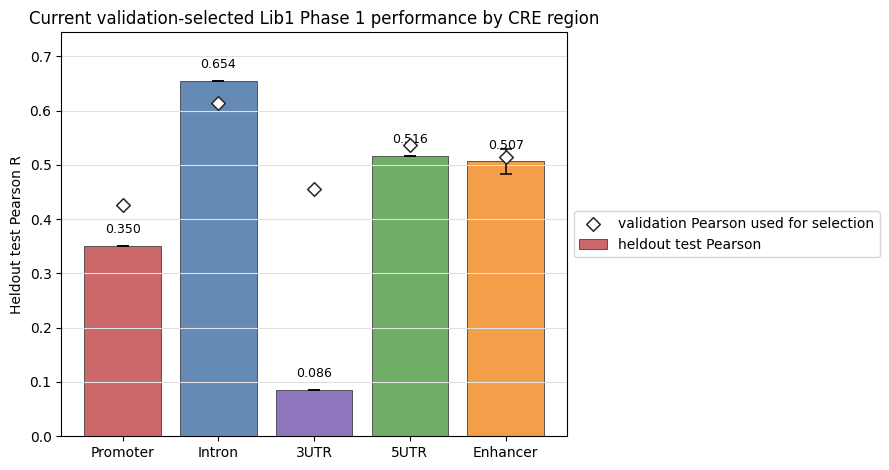

In [7]:
REGION_COLORS = {
    "Promoter": "#c44e52",
    "Intron": "#4c78a8",
    "3UTR": "#7b61b3",
    "5UTR": "#59a14f",
    "Enhancer": "#f28e2b",
}

fig, ax = plt.subplots(figsize=(9.0, 4.8))
x = np.arange(len(performance_summary))
bar_colors = [REGION_COLORS.get(region, "0.5") for region in performance_summary["region"]]
yerr = performance_summary["test_pearson_se"].fillna(0).to_numpy()
error_kw = {"elinewidth": 1.1, "capsize": 4, "capthick": 1.1}
bars = ax.bar(
    x,
    performance_summary["test_pearson"],
    color=bar_colors,
    alpha=0.86,
    edgecolor="0.25",
    linewidth=0.7,
    yerr=yerr,
    error_kw=error_kw,
    label="heldout test Pearson",
)
ax.scatter(
    x,
    performance_summary["val_pearson"],
    marker="D",
    s=48,
    facecolors="white",
    edgecolors="0.15",
    linewidths=1.1,
    zorder=4,
    label="validation Pearson used for selection",
)
for xi, row in performance_summary.iterrows():
    ax.text(xi, row["test_pearson"] + 0.018, f"{row['test_pearson']:.3f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(performance_summary["region"])
ax.set_ylabel("Heldout test Pearson R")
ax.set_title("Current validation-selected Lib1 Phase 1 performance by CRE region")
ax.set_ylim(0, max(0.72, float(performance_summary[["val_pearson", "test_pearson"]].max().max()) + 0.09))
ax.grid(axis="y", color="0.88", linewidth=0.8)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=True)
fig.tight_layout()
plt.show()

## Diagnostics and caveats

The primary bar plot follows the validation-selection rule, but a few diagnostics matter for interpretation:

- The heldout sets are deliberately high-barcode and relatively small. In this snapshot, promoter and intron use 250 validation and 250 test rows; 3UTR uses about 194 validation and 194 test rows inferred from the HQ-pool fraction; 5UTR uses 72 validation and 287 test rows from a 1,438-row high-quality pool; enhancer uses 246 validation and 246 test rows per split seed from a roughly 1,229-row high-quality pool.
- Small heldout sets can make validation-vs-test disagreements look dramatic, especially when a single split seed is reused across a broad HPO search.
- The high intron performance may be real biology or assay signal, but it could also reflect the heldout composition: lower target noise, easier sequence-to-expression mapping, high-barcode filtering, or a favorable split seed. The enhancer multi-seed analysis shows why repeated split seeds are useful: heldout test Pearson varies visibly across seeds even for the same selected setting.
- The strict 3UTR validation-selected row is a warning sign: the best validation run does not have the best test performance. That is exactly why the diagnostic max-test table should stay separate from the model-selection table.

Next improvements:

1. Repeat promoter, intron, and 3UTR HPO finalists across multiple split seeds, then report mean +/- SE and the distribution of test Pearson.
2. Add bootstrap confidence intervals for every heldout Pearson, especially for 5UTR where validation has only 72 rows.
3. Keep a final blind test set untouched by HPO, and use validation-only selection for all tuning decisions.
4. Stratify heldout reporting by barcode count, expression quantile, sequence length, and batch/source where available.
5. Add duplicate/near-duplicate sequence checks across train/val/test for each region.
6. Use matched architecture and RC grids across regions before attributing performance differences to architecture or reverse-complement augmentation.

In [8]:
heldout_caveats = performance_summary[[
    "region", "n_val", "n_test", "n_high_quality_rows", "heldout_note", "split_seed", "n_runs_or_seeds",
]].copy()
display(heldout_caveats)

scratch_max_test_display = scratch_max_test[[
    "cre_region", "architecture", "run_family", "run_id", "run_name", "best_epoch", "val_pearson", "test_pearson",
]].sort_values("cre_region").rename(columns={"cre_region": "region"})
display(scratch_max_test_display.round(4))

,region,n_val,n_test,n_high_quality_rows,heldout_note,split_seed,n_runs_or_seeds
0,Promoter,250,250,1931,HQ min barcode 8; configured explicit size / c...,101,336
1,Intron,250,250,1326,HQ min barcode 8; configured explicit size / c...,101,158
2,3UTR,194,194,775,HQ min barcode 8; inferred from rounded HQ fra...,101,447
3,5UTR,72,287,1438,HQ min barcode 8; val/test rows from split sum...,17.0,90
4,Enhancer,246,246,1229,HQ min barcode 8; 246 val and 246 test rows pe...,8 split seeds,8


,region,architecture,run_family,run_id,run_name,best_epoch,val_pearson,test_pearson
315,3UTR,BassetVL,June standard,pn50zxhm,threeprime_modal100_utr_bassetvl_fp32_d1xfzh7y,24,0.2830,0.5869
462,Intron,ResNet1D,June standard,pkc2c2aa,lib1_intron_modal80_resnet1d_scratch_6f4gf0ab,21,0.4831,0.7183
615,Promoter,ResNet1D,June standard,8xqjbyeg,lib1_promoter_resnet1d_scratch_l38rv22u,20,0.2728,0.3932
